# 附录：延长 Transformer 模型的训练时间

In [1]:
import torch.nn as nn

from torch.utils.data import DataLoader

from MyModule import (
    load_data, 
    load_vocab, 
    class_weights, 
    train_model_with_validation, 
    test_model_comprehensive, 
    plot_training_curves,
    print_training_summary,
    save_training_results,
    BowDataset, 
)


train_data = load_data("data/final/train_index.txt", sep=",", is_indexed=True)
val_data = load_data("data/final/val_index.txt", sep=",", is_indexed=True)
test_data = load_data("data/final/test_index.txt", sep=",", is_indexed=True)

# 加载数据
train_dataset = BowDataset(train_data)
val_dataset = BowDataset(val_data)
test_dataset = BowDataset(test_data)

vocab = load_vocab("data/final/vocab.txt")

In [2]:
import numpy as np
import torch

def load_pretrained_embeddings(embedding_path, vocab, embedding_dim=200):
    """根据已有 vocab 构建向量矩阵"""
    embeddings = np.random.normal(scale=0.6, size=(len(vocab), embedding_dim))  # 随机初始化
    with open(embedding_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype='float32')
            if word in vocab.token_to_idx:
                embeddings[vocab[word]] = vector
    return torch.tensor(embeddings, dtype=torch.float32)

embedding_matrix = load_pretrained_embeddings("resources/Word2Vec-100000-small.txt", vocab, embedding_dim=200)

In [3]:
# 超参数设置
embedding_dim = 200
num_class = 3
hidden_dim = 256
batch_size = 32
num_epoch = 30

In [4]:
from MyModule import Transformer, collate_fn_trans

train_data_loader_trans = DataLoader(train_dataset, batch_size=batch_size, collate_fn=collate_fn_trans, shuffle=True)
val_data_loader_trans = DataLoader(val_dataset, batch_size=batch_size, collate_fn=collate_fn_trans, shuffle=False)
test_data_loader_trans = DataLoader(test_dataset, batch_size=1, collate_fn=collate_fn_trans, shuffle=False)

# 加载模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transformer = Transformer(len(vocab), embedding_dim, num_class)
    
transformer.to(device)                         

transformer_pre_emb = Transformer(len(vocab), embedding_dim, num_class, 
                                  pretrained_embedding_matrix=embedding_matrix.clone().detach(), 
                                  freeze=False)
transformer_pre_emb.to(device)

e:\anaconda3\envs\nlpllma\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Transformer(
  (embeddings): Embedding(36576, 200)
  (position_embedding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=200, out_features=200, bias=True)
        )
        (linear1): Linear(in_features=200, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=200, bias=True)
        (norm1): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output): Linear(in_features=200, out_features=3, bias=True)
)

In [5]:
# 训练过程
weights = class_weights(train_data)
criterion = nn.CrossEntropyLoss(weight=weights.to(device))
# optimizer = torch.optim.Adam(transformer_pre_emb.parameters(), lr=0.001)
optimizer = torch.optim.AdamW(transformer.parameters(), lr=2e-5, weight_decay=1e-3)

transformer_history = train_model_with_validation(
    model=transformer,
    train_loader=train_data_loader_trans,
    val_loader=val_data_loader_trans,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epoch,
    device=device
)

Training Epoch 1:   0%|          | 0/9229 [00:00<?, ?it/s]

Epoch 1/30
    Train Loss: 0.9039	Train Accuracy: 0.5523
    Valid Loss: 0.8159	Valid Accuracy: 0.6184
    Valid Precision: 0.6203	Valid Recall: 0.6184	Valid F1: 0.6162
    ✓ New best validation loss: 0.8159
--------------------------------------------------------------------------------


Training Epoch 2:   0%|          | 0/9229 [00:00<?, ?it/s]

Epoch 2/30
    Train Loss: 0.8132	Train Accuracy: 0.6195
    Valid Loss: 0.7676	Valid Accuracy: 0.6489
    Valid Precision: 0.6515	Valid Recall: 0.6489	Valid F1: 0.6464
    ✓ New best validation loss: 0.7676
--------------------------------------------------------------------------------


Training Epoch 3:   0%|          | 0/9229 [00:00<?, ?it/s]

...

Epoch 21/30
    Train Loss: 0.5675	Train Accuracy: 0.7585
    Valid Loss: 0.6147	Valid Accuracy: 0.7350
    Valid Precision: 0.7405	Valid Recall: 0.7350	Valid F1: 0.7340
    No improvement. Patience: 1/3
--------------------------------------------------------------------------------


Training Epoch 22:   0%|          | 0/9229 [00:00<?, ?it/s]

Epoch 22/30
    Train Loss: 0.5619	Train Accuracy: 0.7611
    Valid Loss: 0.6096	Valid Accuracy: 0.7421
    Valid Precision: 0.7432	Valid Recall: 0.7421	Valid F1: 0.7416
    No improvement. Patience: 2/3
--------------------------------------------------------------------------------


Training Epoch 23:   0%|          | 0/9229 [00:00<?, ?it/s]

Epoch 23/30
    Train Loss: 0.5557	Train Accuracy: 0.7642
    Valid Loss: 0.6091	Valid Accuracy: 0.7411
    Valid Precision: 0.7427	Valid Recall: 0.7411	Valid F1: 0.7401
    No improvement. Patience: 3/3
    Early stopping triggered! Best validation loss: 0.6098


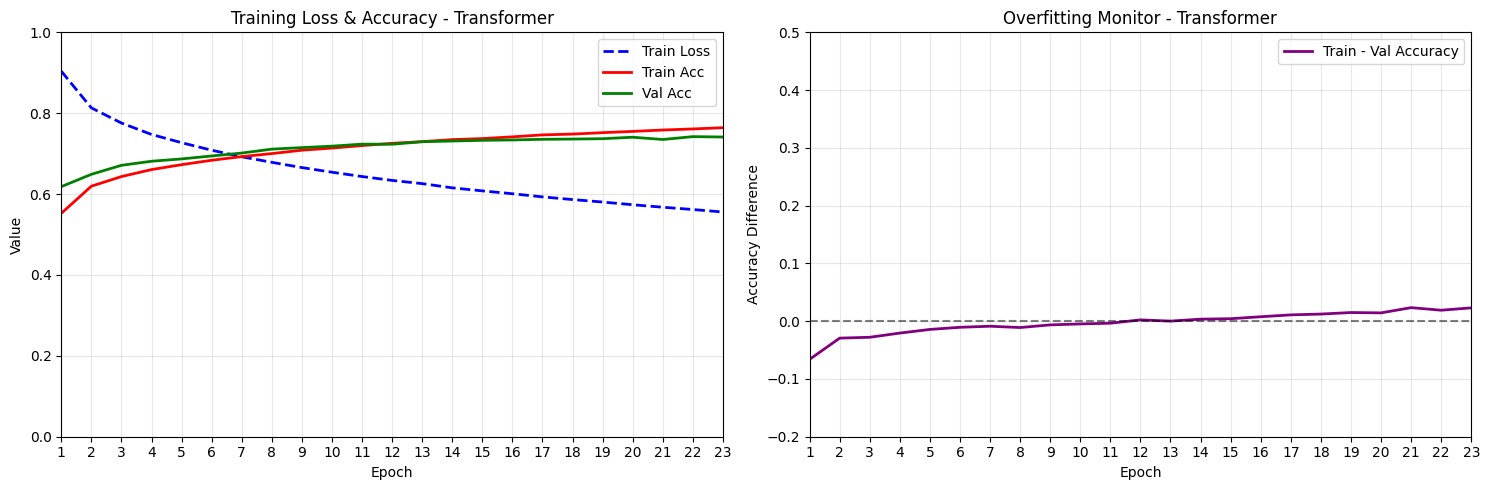


TRAINING SUMMARY
Model Name: Transformer
Final Train Loss: 0.5557
Final Train Accuracy: 0.7642
Final Val Loss: 0.6091
Final Val Accuracy: 0.7411
Best Val Accuracy: 0.7421 (Epoch 22)
Final Overfitting Gap: 0.0230


In [6]:
# 绘制训练曲线
plot_training_curves("Transformer", transformer_history)

# 打印训练摘要
print_training_summary("Transformer", transformer_history)

Testing:   0%|          | 0/63259 [00:00<?, ?it/s]


TEST RESULTS
Model Name: Transformer
Test Accuracy: 0.7457
Test Precision (weighted): 0.7466
Test Recall (weighted): 0.7457
Test F1 Score (weighted): 0.7456

Detailed Test Classification Report:
              precision    recall  f1-score   support

    Negative     0.7726    0.7081    0.7390     18606
     Neutral     0.7036    0.7250    0.7141     19510
    Positive     0.7606    0.7897    0.7749     25143

    accuracy                         0.7457     63259
   macro avg     0.7456    0.7409    0.7427     63259
weighted avg     0.7466    0.7457    0.7456     63259



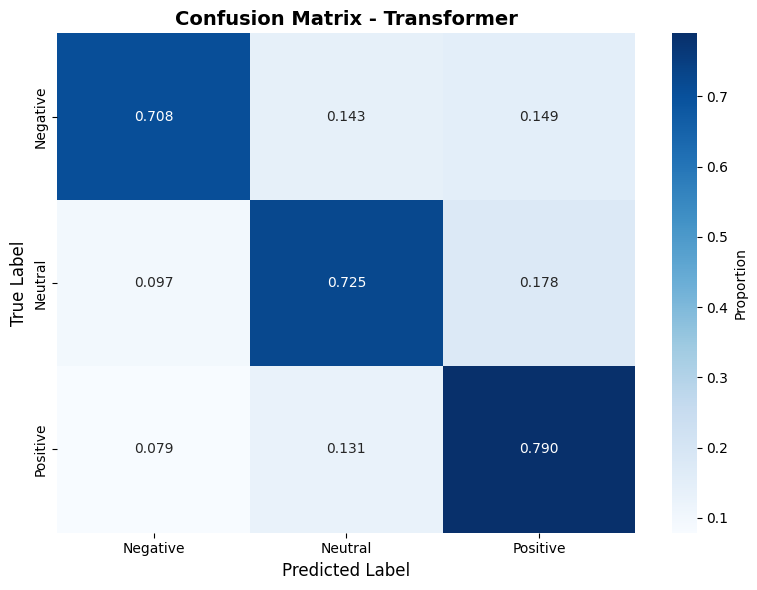


Per-Class Metrics:
------------------------------------------------------------
Negative: Precision=0.7726, Recall=0.7081, F1=0.7390, Support=18606
 Neutral: Precision=0.7036, Recall=0.7250, F1=0.7141, Support=19510
Positive: Precision=0.7606, Recall=0.7897, F1=0.7749, Support=25143


In [7]:
# Transformer 测试过程 - 使用通用框架
transformer_test_results = test_model_comprehensive(
    model=transformer,
    model_name="Transformer",
    test_loader=test_data_loader_trans,
    device=device
)

In [8]:
# 保存Transformer训练结果
save_training_results(
    model=transformer_pre_emb,
    model_name="Transformer",
    set_epochs=num_epoch,
    actual_epochs=len(transformer_history['train_losses']),
    device=device,
    use_pretrained_embeddings=True,
    training_history=transformer_history,
    test_results=transformer_test_results,
)

✓ 训练结果已保存到 results/model_training_results.json
  - 模型: Transformer (Transformer)
  - 实际训练轮数: 23
  - 测试准确率: 0.7457
  - 测试F1分数: 0.7456
  - 记录时间: 2025-12-26 16:52:08
  - 总记录数: 84


In [9]:
# 训练过程
weights = class_weights(train_data)
criterion = nn.CrossEntropyLoss(weight=weights.to(device))
# optimizer = torch.optim.Adam(transformer_pre_emb.parameters(), lr=0.001)
optimizer = torch.optim.AdamW(transformer_pre_emb.parameters(), lr=2e-5, weight_decay=1e-3)

transformer_history = train_model_with_validation(
    model=transformer_pre_emb,
    train_loader=train_data_loader_trans,
    val_loader=val_data_loader_trans,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epoch,
    device=device
)

Training Epoch 1:   0%|          | 0/9229 [00:00<?, ?it/s]

Epoch 1/30
    Train Loss: 0.8047	Train Accuracy: 0.6245
    Valid Loss: 0.6723	Valid Accuracy: 0.7105
    Valid Precision: 0.7101	Valid Recall: 0.7105	Valid F1: 0.7103
    ✓ New best validation loss: 0.6723
--------------------------------------------------------------------------------


Training Epoch 2:   0%|          | 0/9229 [00:00<?, ?it/s]

Epoch 2/30
    Train Loss: 0.6943	Train Accuracy: 0.6964
    Valid Loss: 0.6350	Valid Accuracy: 0.7282
    Valid Precision: 0.7279	Valid Recall: 0.7282	Valid F1: 0.7267
    ✓ New best validation loss: 0.6350
--------------------------------------------------------------------------------


Training Epoch 3:   0%|          | 0/9229 [00:00<?, ?it/s]

...

Epoch 21/30
    Train Loss: 0.5099	Train Accuracy: 0.7846
    Valid Loss: 0.5506	Valid Accuracy: 0.7676
    Valid Precision: 0.7678	Valid Recall: 0.7676	Valid F1: 0.7675
    No improvement. Patience: 1/3
--------------------------------------------------------------------------------


Training Epoch 22:   0%|          | 0/9229 [00:00<?, ?it/s]

Epoch 22/30
    Train Loss: 0.5070	Train Accuracy: 0.7867
    Valid Loss: 0.5518	Valid Accuracy: 0.7681
    Valid Precision: 0.7681	Valid Recall: 0.7681	Valid F1: 0.7680
    No improvement. Patience: 2/3
--------------------------------------------------------------------------------


Training Epoch 23:   0%|          | 0/9229 [00:00<?, ?it/s]

Epoch 23/30
    Train Loss: 0.5023	Train Accuracy: 0.7889
    Valid Loss: 0.5573	Valid Accuracy: 0.7690
    Valid Precision: 0.7692	Valid Recall: 0.7690	Valid F1: 0.7679
    No improvement. Patience: 3/3
    Early stopping triggered! Best validation loss: 0.5496


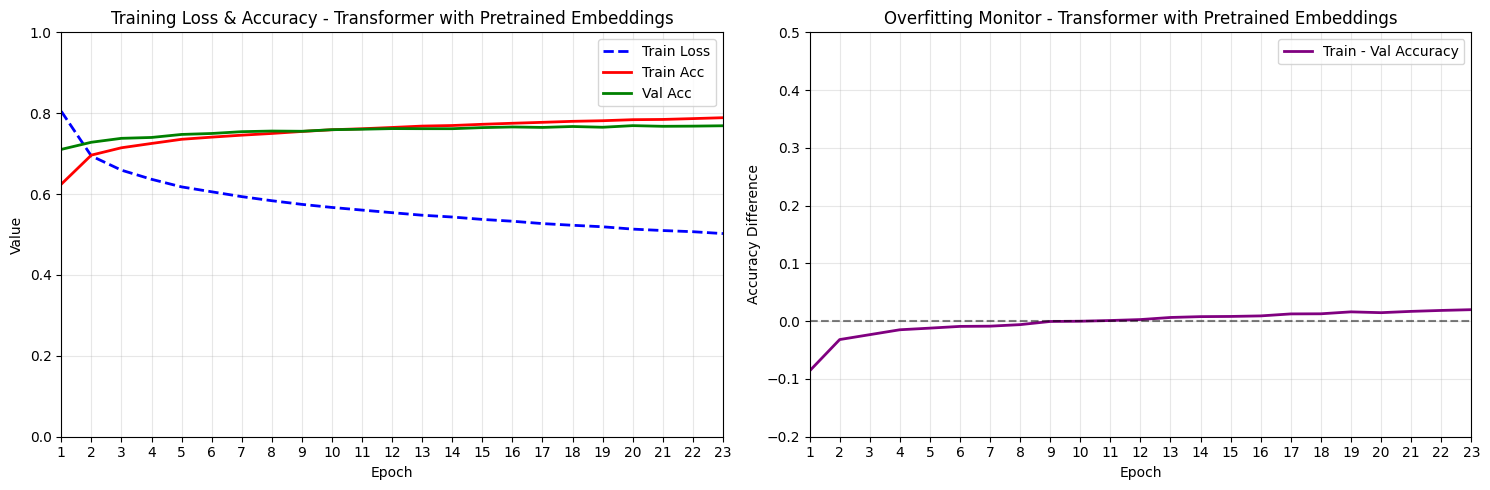


TRAINING SUMMARY
Model Name: Transformer with Pretrained Embeddings with Pretrained Embeddings
Final Train Loss: 0.5023
Final Train Accuracy: 0.7889
Final Val Loss: 0.5573
Final Val Accuracy: 0.7690
Best Val Accuracy: 0.7693 (Epoch 20)
Final Overfitting Gap: 0.0199


In [10]:
# 绘制训练曲线
plot_training_curves("Transformer with Pretrained Embeddings", transformer_history)

# 打印训练摘要
print_training_summary("Transformer with Pretrained Embeddings with Pretrained Embeddings", transformer_history)

Testing:   0%|          | 0/63259 [00:00<?, ?it/s]


TEST RESULTS
Model Name: Transformer with Pretrained Embeddings
Test Accuracy: 0.7720
Test Precision (weighted): 0.7716
Test Recall (weighted): 0.7720
Test F1 Score (weighted): 0.7718

Detailed Test Classification Report:
              precision    recall  f1-score   support

    Negative     0.7723    0.7770    0.7746     18606
     Neutral     0.7437    0.7233    0.7333     19510
    Positive     0.7929    0.8061    0.7995     25143

    accuracy                         0.7720     63259
   macro avg     0.7696    0.7688    0.7691     63259
weighted avg     0.7716    0.7720    0.7718     63259



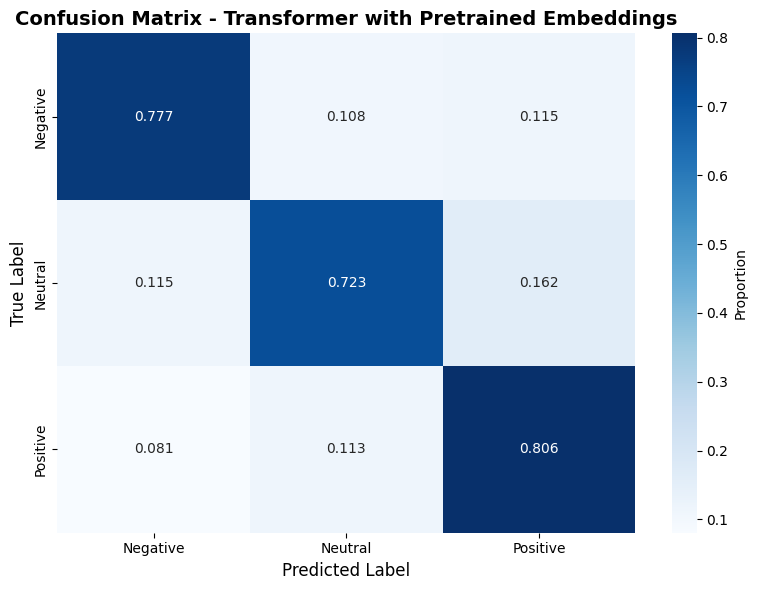


Per-Class Metrics:
------------------------------------------------------------
Negative: Precision=0.7723, Recall=0.7770, F1=0.7746, Support=18606
 Neutral: Precision=0.7437, Recall=0.7233, F1=0.7333, Support=19510
Positive: Precision=0.7929, Recall=0.8061, F1=0.7995, Support=25143


In [11]:
# Transformer 测试过程 - 使用通用框架
transformer_test_results = test_model_comprehensive(
    model=transformer_pre_emb,
    model_name="Transformer with Pretrained Embeddings",
    test_loader=test_data_loader_trans,
    device=device
)

In [12]:
# 保存Transformer训练结果
save_training_results(
    model=transformer_pre_emb,
    model_name="Transformer with Pretrained Embeddings",
    set_epochs=num_epoch,
    actual_epochs=len(transformer_history['train_losses']),
    device=device,
    use_pretrained_embeddings=True,
    training_history=transformer_history,
    test_results=transformer_test_results,
)

✓ 训练结果已保存到 results/model_training_results.json
  - 模型: Transformer with Pretrained Embeddings (Transformer)
  - 实际训练轮数: 23
  - 测试准确率: 0.7720
  - 测试F1分数: 0.7718
  - 记录时间: 2025-12-26 17:22:57
  - 总记录数: 85
